In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [2]:
# Load the Wisconsin Breast Cancer dataset from sklearn's built-in datasets
from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()


In [3]:
# Convert the dataset into a pandas DataFrame for easier manipulation
data = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)


In [4]:
# Add the target column to the DataFrame for reference
data['target'] = cancer_data.target


In [5]:
# Display the first few rows of the dataset to understand its structure
data
# Drop the target column as it is not needed for unsupervised learning (clustering)
# We only want to cluster based on the features
data_features = data.drop(columns=['target'])


In [6]:
# Standardize the features to ensure all variables contribute equally to the clustering
# StandardScaler scales the data to have a mean of 0 and a standard deviation of 1
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_features)


In [7]:
# Convert the scaled data back to a DataFrame for easier manipulation
data_scaled_df = pd.DataFrame(data_scaled, columns=data_features.columns)
data_scaled_df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,2.110995,0.721473,2.060786,2.343856,1.041842,0.219060,1.947285,2.320965,-0.312589,-0.931027,...,1.901185,0.117700,1.752563,2.015301,0.378365,-0.273318,0.664512,1.629151,-1.360158,-0.709091
565,1.704854,2.085134,1.615931,1.723842,0.102458,-0.017833,0.693043,1.263669,-0.217664,-1.058611,...,1.536720,2.047399,1.421940,1.494959,-0.691230,-0.394820,0.236573,0.733827,-0.531855,-0.973978
566,0.702284,2.045574,0.672676,0.577953,-0.840484,-0.038680,0.046588,0.105777,-0.809117,-0.895587,...,0.561361,1.374854,0.579001,0.427906,-0.809587,0.350735,0.326767,0.414069,-1.104549,-0.318409
567,1.838341,2.336457,1.982524,1.735218,1.525767,3.272144,3.296944,2.658866,2.137194,1.043695,...,1.961239,2.237926,2.303601,1.653171,1.430427,3.904848,3.197605,2.289985,1.919083,2.219635


In [8]:
# Apply k-means clustering
# Initialize the KMeans algorithm with 2 clusters (malignant and benign)
# random_state ensures reproducibility
kmeans = KMeans(n_clusters=2, random_state=42)


In [9]:
# Fit the model to the scaled data and predict cluster labels
clusters = kmeans.fit_predict(data_scaled_df)
# Add the cluster labels to the original DataFrame for analysis
data['cluster'] = clusters
data[['target', 'cluster']]


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


,target,cluster
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
...,...,...
564,0,0
565,0,0
566,0,0
567,0,0


In [10]:
# Use PCA (Principal Component Analysis) to reduce the data to 2 dimensions for visualization
# PCA helps in visualizing high-dimensional data in a 2D space
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_scaled_df)



In [11]:
# Create a DataFrame for the PCA-transformed data
pca_df = pd.DataFrame(data_pca, columns=['PCA1', 'PCA2'])
pca_df['cluster'] = clusters



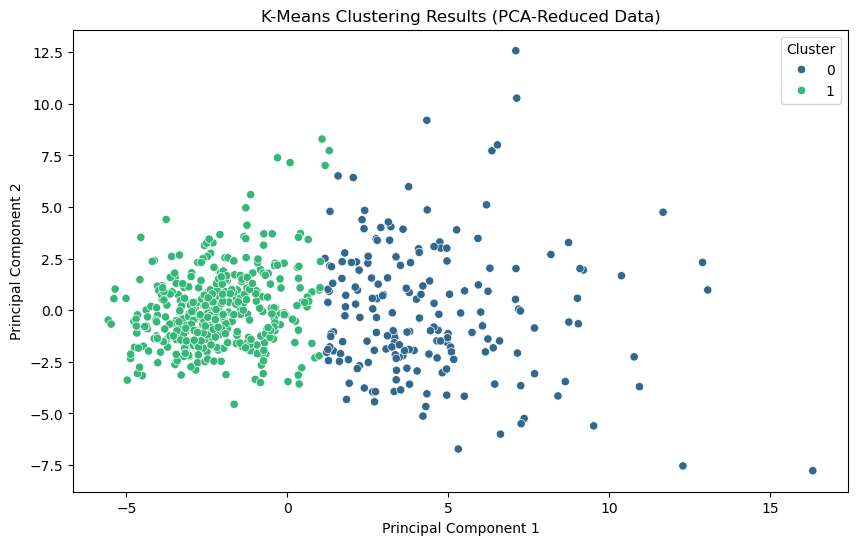

In [12]:
# Plot the clusters in the 2D PCA space
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='cluster', data=pca_df, palette='viridis')
plt.title('K-Means Clustering Results (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()